Model loaded from saved_models/reinforce_agent_model.pth
Loaded model from saved_models/reinforce_agent_model.pth
Starting training...
Running experiment 1/100
Episode 100/200, Total Reward: 4
Episode 200/200, Total Reward: 4

Average score after 200 episodes:
  Player 1: 8.53
  Player 2: 12.23
  Player 3: 3.87
  Player 4: 13.99

Last 10 Episodes - Score Cards and Player's Cards:

Episode 1:
  Score Cards   :  3  5  7  1 10 -5  4 -4  6  8 -2  2  9 -3 -1
  Player 1 Cards: 14 15 13 12 10  7 11  9  8  6  1  3  2  4  5
  Player 2 Cards:  7 15 14  9  1 10 13 11 12  8  6  2  4  3  5
  Player 3 Cards:  4 15 14 12  6 13 11 10  9  8  7  5  2  3  1
  Player 4 Cards: 15 14 13 12 11  1 10  2  9  8  3  7  6  4  5

Episode 2:
  Score Cards   :  8  6 10  1 -4 -1 -5  5  9 -2  4  2 -3  7  3
  Player 1 Cards: 14 15 12 13 10  4 11  9  6  1  8  3  2  5  7
  Player 2 Cards:  9 15 14  6  5  8 12 13  3 10 11  1  2  7  4
  Player 3 Cards:  8 15  6 10 14 13 12 11  1  9  7  5  4  3  2
  Player 4 Cards: 15 14  7

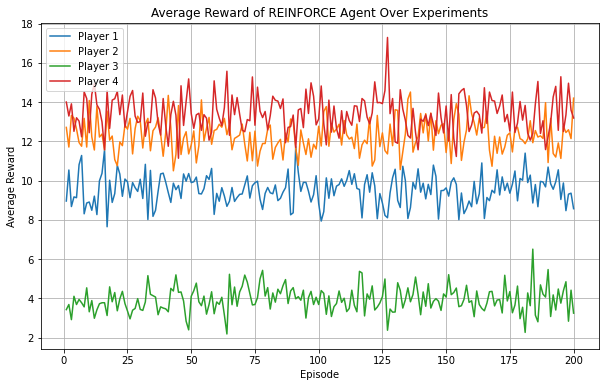

Graph saved as 'average_rewards_over_experiments.png'


<Figure size 432x288 with 0 Axes>

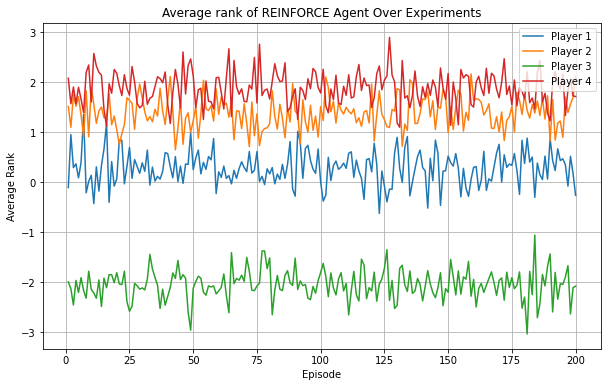

Graph saved as 'average_ranks_over_experiments.png'
Execution time: 261.3882188796997 seconds
Model saved to saved_models/reinforce_agent_model.pth
Training complete. Model saved.


<Figure size 432x288 with 0 Axes>

In [1]:
# main.py

# モジュールのインポート
from config import config                  # ハイパーパラメータの読み込み
from agent.reinforce_agent import REINFORCEAgent       # エージェントのインポートはここを変更
from environment.hagetaka_env import HagetakaEnv  # カスタム環境のインポート
from train.training_loop_v2 import train_agent  # トレーニングループのインポート

import os
import time


# モデルやログの保存用ディレクトリを作成
os.makedirs("saved_models", exist_ok=True)
os.makedirs("logs", exist_ok=True)

def main():
    # 環境とエージェントの初期化
    environment = HagetakaEnv()
    
    #エージェント名を変更する
    agent = REINFORCEAgent(config['agent']['state_size'], config['agent']['action_size'], config['agent']['learning_rate'])
    
    model_path = "saved_models/reinforce_agent_model.pth" # エージェントごとの学習状況を保存するパス
    try:
        agent.load(model_path)
        print(f"Loaded model from {model_path}")
    except FileNotFoundError:
        print(f"No model found at {model_path}. Please train the model first.")
        return

    start_time = time.time()
    
    # トレーニング開始
    print("Starting training...")
    train_agent(agent, environment, config['training']['n_episodes'], config['agent']['gamma'], config['training']['num_experiments'])  
    
    end_time = time.time()
    
    execution_time = end_time - start_time
    print(f"Execution time: {execution_time} seconds")
    
    # 学習済みモデルの保存
    agent.save("saved_models/reinforce_agent_model.pth") # エージェントごとに学習状況を保存
    print("Training complete. Model saved.")

if __name__ == "__main__":
    main()
